In [1]:
!pip -q install opencv-python pillow moviepy

In [2]:
from google.colab import files
import os
import shutil

print("Upload your CONSTANT FRAME image")
print("Do NOT upload the changing photos here.")

uploaded = files.upload()

frame_filename = list(uploaded.keys())[0]

FRAME_PATH = "/content/constant_frame.png"

shutil.copy(
    frame_filename,
    FRAME_PATH
)

print()
print("Constant frame saved:")
print(FRAME_PATH)

Upload your CONSTANT FRAME image
Do NOT upload the changing photos here.


Saving finsl_frame_v2.png to finsl_frame_v2.png

Constant frame saved:
/content/constant_frame.png


In [12]:
from google.colab import files
import os
import shutil

IMAGE_FOLDER = "/content/input_images"

os.makedirs(
    IMAGE_FOLDER,
    exist_ok=True
)

print("Upload ALL images for the video.")

uploaded_images = files.upload()

for filename in uploaded_images.keys():

    destination = os.path.join(
        IMAGE_FOLDER,
        filename
    )

    shutil.copy(
        filename,
        destination
    )

print()
print("Uploaded images:")

for filename in sorted(
    os.listdir(IMAGE_FOLDER)
):
    print("✓", filename)

Upload ALL images for the video.


Saving 001.jpg to 001.jpg
Saving 002.jpg to 002.jpg
Saving 003.jpg to 003.jpg
Saving 004.jpg to 004.jpg

Uploaded images:
✓ .ipynb_checkpoints
✓ 001.jpg
✓ 002.jpg
✓ 003.jpg
✓ 004.jpg


Constant frame size: (941, 1672)


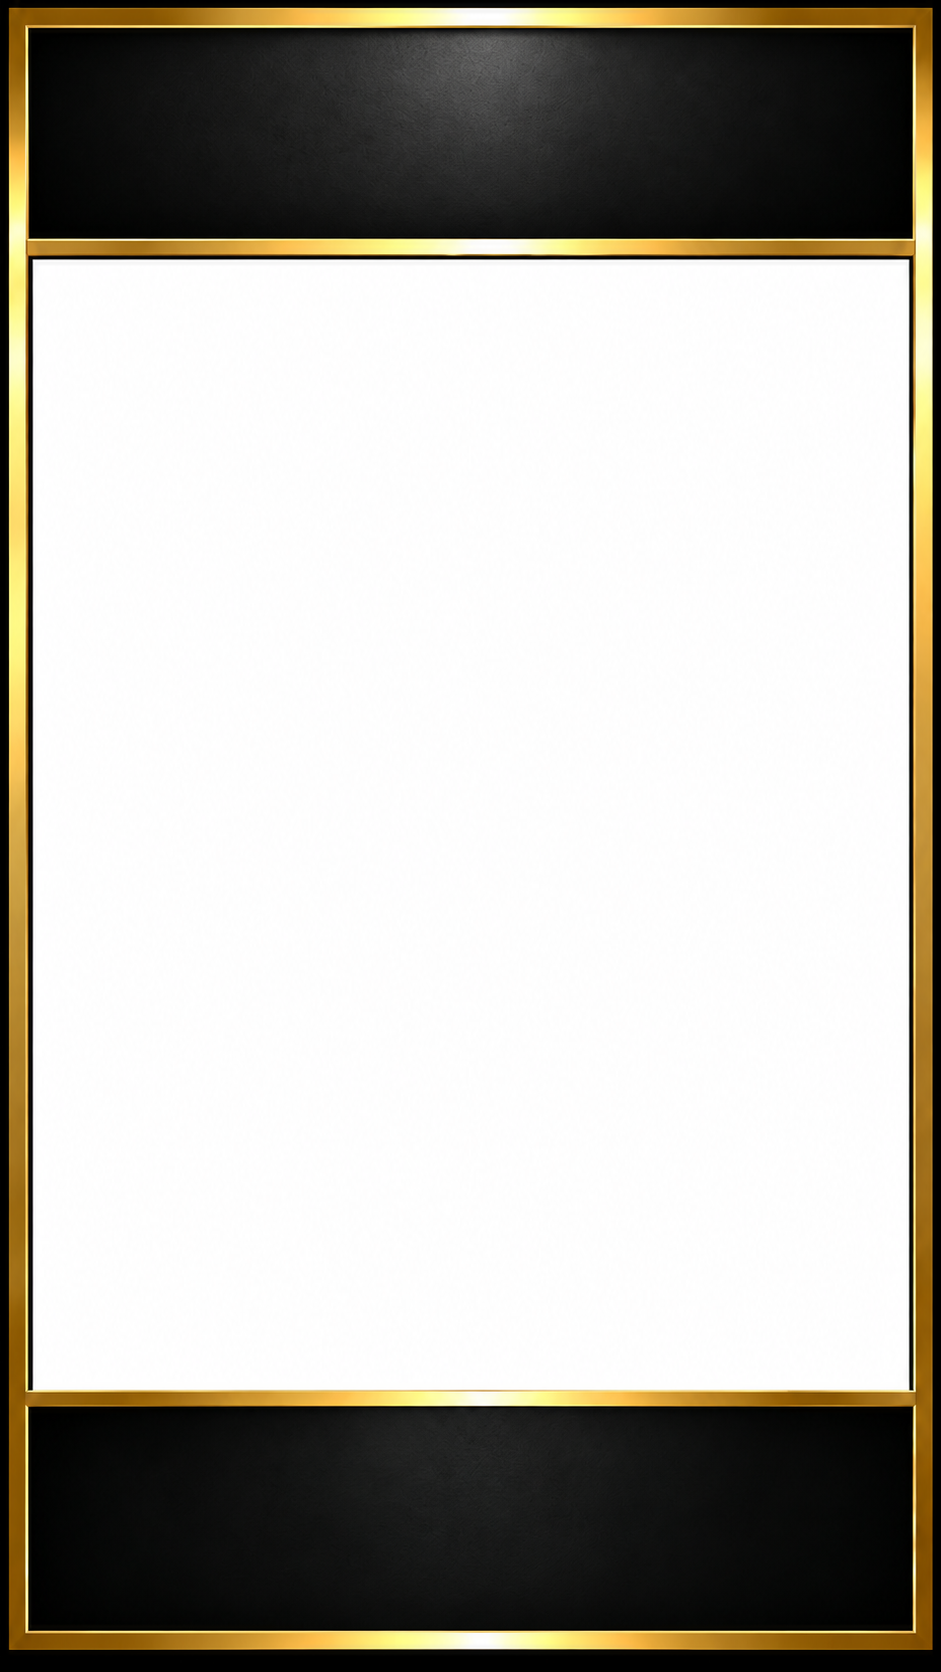


Input images:
001.jpg -> (170, 297)
002.jpg -> (201, 250)
003.jpg -> (800, 1200)
004.jpg -> (401, 498)


In [13]:
from PIL import Image
from IPython.display import display
import os

# -----------------------------------------
# CONSTANT FRAME
# -----------------------------------------

frame = Image.open(FRAME_PATH)

print(
    "Constant frame size:",
    frame.size
)

display(frame)


# -----------------------------------------
# INPUT IMAGES
# -----------------------------------------

print("\nInput images:")

for filename in sorted(
    os.listdir(IMAGE_FOLDER)
):

    path = os.path.join(
        IMAGE_FOLDER,
        filename
    )

    if filename.lower().endswith(
        (".jpg", ".jpeg", ".png", ".webp")
    ):

        img = Image.open(path)

        print(
            filename,
            "->",
            img.size
        )

In [14]:
# ============================================================
# VIDEO SIZE — YOUTUBE SHORTS
# ============================================================

VIDEO_WIDTH = 1080
VIDEO_HEIGHT = 1920

FPS = 30


# ============================================================
# IMAGE DURATION
# ============================================================

# Each image stays for 4.5 seconds.

IMAGE_DURATION = 4.5


# ============================================================
# ZOOM-OUT
# ============================================================

# Image starts slightly zoomed in
START_ZOOM = 1.08

# Image ends at normal size
END_ZOOM = 1.00


# ============================================================
# INNER IMAGE BOX
# ============================================================

IMAGE_X1 = 45
IMAGE_Y1 = 300

IMAGE_X2 = 1035
IMAGE_Y2 = 1620

INNER_WIDTH = IMAGE_X2 - IMAGE_X1
INNER_HEIGHT = IMAGE_Y2 - IMAGE_Y1


# ============================================================
# TOP TEXT BOX
# ============================================================

TEXT_BOX_X1 = 45
TEXT_BOX_Y1 = 45

TEXT_BOX_X2 = 1035
TEXT_BOX_Y2 = 275

TEXT_BOX_WIDTH = (
    TEXT_BOX_X2 -
    TEXT_BOX_X1
)

TEXT_BOX_HEIGHT = (
    TEXT_BOX_Y2 -
    TEXT_BOX_Y1
)


# ============================================================
# TEXT
# ============================================================

TOP_TEXT = (
    "NANI HINDI AND TAMIL AUDIENCE "
    "RAISE CHESINA COMPLAINT PATTINCHUKUNNARU"
)


# ============================================================
# TEXT COLOR
# ============================================================

# White
TEXT_COLOR = (
    255,
    255,
    255
)


# ============================================================
# TEXT FONT
# ============================================================

FONT_SIZE = 48

FONT_PATH = (
    "/usr/share/fonts/truetype/dejavu/"
    "DejaVuSans-Bold.ttf"
)


# ============================================================
# TEXT MARGINS
# ============================================================

TEXT_MARGIN_LEFT = 25
TEXT_MARGIN_RIGHT = 25
TEXT_MARGIN_TOP = 20
TEXT_MARGIN_BOTTOM = 20


# ============================================================
# OUTPUT
# ============================================================

OUTPUT_VIDEO = (
    "/content/youtube_short.mp4"
)

In [6]:
!apt-get -qq update
!apt-get -qq install fonts-noto-core fonts-noto-extra

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-noto-mono.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack .../fonts-noto-mono_20201225-2_all.deb ...
Unpacking fonts-noto-mono (20201225-2) ...
Selecting previously unselected package fonts-noto-core.
Preparing to unpack .../fonts-noto-core_20201225-2_all.deb ...
Unpacking fonts-noto-core (20201225-2) ...
Selecting previously unselected package fonts-noto-extra.
Preparing to unpack .../fonts-noto-extra_20201225-2_all.deb ...
Unpacking fonts-noto-extra (20201225-2) ...
Setting up fonts-noto-mono (20201225-2) ...
Setting up fonts-noto-extra (20201225-2) ...
Setting up fonts-noto-core (20201225-2) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...


In [15]:
import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFont


def load_font(size):

    try:

        return ImageFont.truetype(
            FONT_PATH,
            size
        )

    except:

        return ImageFont.load_default()


def calculate_text_lines(
    draw,
    text,
    font,
    max_width
):

    words = text.split()

    lines = []

    current_line = ""

    for word in words:

        test_line = (
            current_line + " " + word
        ).strip()

        bbox = draw.textbbox(
            (0, 0),
            test_line,
            font=font
        )

        width = (
            bbox[2] -
            bbox[0]
        )

        if width <= max_width:

            current_line = test_line

        else:

            if current_line:
                lines.append(
                    current_line
                )

            current_line = word

    if current_line:
        lines.append(
            current_line
        )

    return lines


def draw_safe_text(frame):

    image = Image.fromarray(
        cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )
    )

    draw = ImageDraw.Draw(image)

    max_width = (
        TEXT_BOX_WIDTH
        - TEXT_MARGIN_LEFT
        - TEXT_MARGIN_RIGHT
    )

    max_height = (
        TEXT_BOX_HEIGHT
        - TEXT_MARGIN_TOP
        - TEXT_MARGIN_BOTTOM
    )

    # Start with configured font size
    font_size = FONT_SIZE

    while font_size >= 20:

        font = load_font(
            font_size
        )

        lines = calculate_text_lines(
            draw,
            TOP_TEXT,
            font,
            max_width
        )

        line_spacing = 8

        total_height = 0

        for line in lines:

            bbox = draw.textbbox(
                (0, 0),
                line,
                font=font
            )

            line_height = (
                bbox[3] -
                bbox[1]
            )

            total_height += (
                line_height +
                line_spacing
            )

        total_height -= line_spacing

        if total_height <= max_height:
            break

        font_size -= 2

    # --------------------------------------------------------
    # Vertical centering
    # --------------------------------------------------------

    start_y = (
        TEXT_BOX_Y1
        + (
            TEXT_BOX_HEIGHT -
            total_height
        ) / 2
    )

    # --------------------------------------------------------
    # Draw each line
    # --------------------------------------------------------

    for line in lines:

        bbox = draw.textbbox(
            (0, 0),
            line,
            font=font
        )

        line_width = (
            bbox[2] -
            bbox[0]
        )

        # Center horizontally
        x = (
            TEXT_BOX_X1
            + (
                TEXT_BOX_WIDTH -
                line_width
            ) / 2
        )

        draw.text(
            (
                int(x),
                int(start_y)
            ),
            line,
            font=font,
            fill=TEXT_COLOR,

            # Black outline
            stroke_width=2,
            stroke_fill=(0, 0, 0)
        )

        line_height = (
            bbox[3] -
            bbox[1]
        )

        start_y += (
            line_height +
            line_spacing
        )

    return cv2.cvtColor(
        np.array(image),
        cv2.COLOR_RGB2BGR
    )

In [16]:
import cv2
import os
import glob


def prepare_image(
    image_path,
    target_width,
    target_height
):

    image = cv2.imread(
        image_path
    )

    if image is None:

        raise ValueError(
            f"Cannot read: {image_path}"
        )

    h, w = image.shape[:2]

    # -----------------------------------------
    # Scale image to COVER the entire box
    # -----------------------------------------

    scale = max(
        target_width / w,
        target_height / h
    )

    new_width = int(
        w * scale
    )

    new_height = int(
        h * scale
    )

    image = cv2.resize(
        image,
        (
            new_width,
            new_height
        ),
        interpolation=cv2.INTER_LANCZOS4
    )

    # -----------------------------------------
    # Center crop
    # -----------------------------------------

    x = (
        new_width -
        target_width
    ) // 2

    y = (
        new_height -
        target_height
    ) // 2

    image = image[
        y:y + target_height,
        x:x + target_width
    ]

    return image

In [17]:
import math


def create_zoom_out(
    image,
    progress,
    target_width,
    target_height
):

    # Smooth cinematic movement

    smooth_progress = (
        1 -
        math.cos(
            progress * math.pi
        )
    ) / 2

    zoom = (
        START_ZOOM
        +
        (
            END_ZOOM -
            START_ZOOM
        )
        *
        smooth_progress
    )

    h, w = image.shape[:2]

    new_width = int(
        w * zoom
    )

    new_height = int(
        h * zoom
    )

    zoomed = cv2.resize(
        image,
        (
            new_width,
            new_height
        ),
        interpolation=cv2.INTER_LANCZOS4
    )

    # Center crop

    x = (
        new_width -
        target_width
    ) // 2

    y = (
        new_height -
        target_height
    ) // 2

    result = zoomed[
        y:y + target_height,
        x:x + target_width
    ]

    return result

In [18]:
import cv2
import numpy as np
import os


# ============================================================
# LOAD CONSTANT FRAME
# ============================================================

frame = cv2.imread(
    FRAME_PATH
)

if frame is None:

    raise FileNotFoundError(
        "Constant frame not found."
    )


# ============================================================
# RESIZE FRAME TO EXACT YOUTUBE SHORT SIZE
# ============================================================

frame = cv2.resize(
    frame,
    (
        VIDEO_WIDTH,
        VIDEO_HEIGHT
    ),
    interpolation=cv2.INTER_LANCZOS4
)


print(
    "Final video size:",
    frame.shape[1],
    "x",
    frame.shape[0]
)


# ============================================================
# ADD SAFE HEADLINE
# ============================================================

frame = draw_safe_text(
    frame
)


# ============================================================
# FIND ALL IMAGES
# ============================================================

extensions = [
    "*.jpg",
    "*.jpeg",
    "*.png",
    "*.webp",
    "*.JPG",
    "*.JPEG",
    "*.PNG",
    "*.WEBP"
]

image_files = []

for extension in extensions:

    image_files.extend(
        glob.glob(
            os.path.join(
                IMAGE_FOLDER,
                extension
            )
        )
    )


image_files.sort()


if len(image_files) == 0:

    raise ValueError(
        "No images found."
    )


print(
    f"Found {len(image_files)} images."
)


# ============================================================
# VIDEO WRITER
# ============================================================

fourcc = cv2.VideoWriter_fourcc(
    *"mp4v"
)

writer = cv2.VideoWriter(
    OUTPUT_VIDEO,
    fourcc,
    FPS,
    (
        VIDEO_WIDTH,
        VIDEO_HEIGHT
    )
)


# ============================================================
# FRAMES PER IMAGE
# ============================================================

frames_per_image = int(
    IMAGE_DURATION *
    FPS
)


# ============================================================
# PROCESS IMAGES
# ============================================================

for index, image_path in enumerate(
    image_files
):

    print(
        f"Processing "
        f"{index + 1}/{len(image_files)} : "
        f"{os.path.basename(image_path)}"
    )


    # -----------------------------------------
    # Prepare image
    # -----------------------------------------

    image = prepare_image(
        image_path,
        INNER_WIDTH,
        INNER_HEIGHT
    )


    # -----------------------------------------
    # Create animation
    # -----------------------------------------

    for frame_number in range(
        frames_per_image
    ):

        progress = (
            frame_number /
            max(
                frames_per_image - 1,
                1
            )
        )


        animated_image = create_zoom_out(
            image,
            progress,
            INNER_WIDTH,
            INNER_HEIGHT
        )


        # -------------------------------------
        # Copy permanent frame
        # -------------------------------------

        output_frame = frame.copy()


        # -------------------------------------
        # Put changing image inside box
        # -------------------------------------

        output_frame[
            IMAGE_Y1:IMAGE_Y2,
            IMAGE_X1:IMAGE_X2
        ] = animated_image


        # -------------------------------------
        # Write frame
        # -------------------------------------

        writer.write(
            output_frame
        )


# ============================================================
# FINISH
# ============================================================

writer.release()

print()
print("========================================")
print("       VIDEO CREATED SUCCESSFULLY")
print("========================================")
print()
print("File:")
print(OUTPUT_VIDEO)

print()
print(
    "Duration:",
    round(
        len(image_files) *
        IMAGE_DURATION,
        2
    ),
    "seconds"
)

Final video size: 1080 x 1920
Found 4 images.
Processing 1/4 : 001.jpg
Processing 2/4 : 002.jpg
Processing 3/4 : 003.jpg
Processing 4/4 : 004.jpg

       VIDEO CREATED SUCCESSFULLY

File:
/content/youtube_short.mp4

Duration: 18.0 seconds


In [19]:
from IPython.display import Video

Video(
    OUTPUT_VIDEO,
    embed=True
)

Output hidden; open in https://colab.research.google.com to view.